**Basic CNN Model**

In [13]:
list_paths = []
for subdir, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        filepath = subdir + os.sep + file
        list_paths.append(filepath)

In [14]:
list_train = [filepath for filepath in list_paths if "train/" in filepath]
# seed(420)
# shuffle(list_train)

In [15]:
def get_class_from_path(filepath):
    return os.path.dirname(filepath).split(os.sep)[-1]

train_labels = [get_class_from_path(filepath) for filepath in list_train]

In [16]:
label_encoder = LabelEncoder()
train_encoded_labels = label_encoder.fit_transform(train_labels)

In [6]:
def preprocess_image(image_path):
    image = cv2.imread(image_path)  # Load image using OpenCV
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized_image = cv2.resize(image, (512, 512))
    normalized_image = (resized_image / 127.5)-1
    return normalized_image
    # patch_size = (64, 64)  
    # patches = []
    # patch_height, patch_width = patch_size
    # img_height, img_width, _ = image.shape

    # for y in range(0, img_height, patch_height):
    #     for x in range(0, img_width, patch_width):
    #         patch = image[y:y+patch_height, x:x+patch_width]
    #         # Ensure patch size matches
    #         if patch.shape[:2] == (patch_height, patch_width):
    #             patches.append(patch)

    # return patches
images = [preprocess_image(filepath) for filepath in list_train]
labels_subset = train_encoded_labels

In [17]:
X_train, X_val, y_train, y_val = train_test_split(images, labels_subset, test_size=0.2, random_state=42,stratify=labels_subset)

NameError: name 'images' is not defined

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # num_classes = number of camera models
])
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    np.array(X_train), np.array(y_train),  # Training data
    validation_data=(np.array(X_val), np.array(y_val)),  # Validation data
    epochs=10,
    batch_size=32,
    callbacks=[reduce_lr]
)
val_loss, val_accuracy = model.evaluate(np.array(X_val), np.array(y_val))
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.1186 - loss: 2.3454 - val_accuracy: 0.2018 - val_loss: 2.2027 - learning_rate: 0.0010
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2156 - loss: 2.1562 - val_accuracy: 0.2600 - val_loss: 2.0752 - learning_rate: 0.0010
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2848 - loss: 2.0267 - val_accuracy: 0.3109 - val_loss: 1.9314 - learning_rate: 0.0010
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3871 - loss: 1.8001 - val_accuracy: 0.3964 - val_loss: 1.7906 - learning_rate: 0.0010
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4523 - loss: 1.5757 - val_accuracy: 0.4200 - val_loss: 1.7479 - learning_rate: 0.0010
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5347 - loss: 1.3245 - val_accuracy: 0.4418 - val_loss: 1.6611 - learning_rate: 0.0010
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6270 - loss: 1.1104 - val_a

In [45]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Load pre-trained DenseNet121 model without the top layer (classifier)
base_model = DenseNet121(weights=None, include_top=False, input_shape=(512, 512, 3))

# Load the manually downloaded weights
base_model.load_weights('/kaggle/input/densenet/densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5')  # Replace with your weight file path

# Freeze the base model layers to prevent them from being updated during training
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global average pooling to reduce dimensionality
x = Dense(64, activation='relu')(x)  # Fully connected layer with 256 neurons
x = Dropout(0.3)(x)  # Dropout to reduce overfitting
x = Dense(32, activation='relu')(x)  # Fully connected layer with 256 neurons
x = Dropout(0.3)(x)  # Dropout to reduce overfitting
output = Dense(10, activation='softmax')(x)  # Output layer for 10 classes (camera models)

# Create a new model with the pre-trained base model and custom head
model = Model(inputs=base_model.input, outputs=output)

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
)

# Compile the model with Adam optimizer
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
# history = model.fit(
#     np.array(X_train), np.array(y_train),  # Training data
#     validation_data=(np.array(X_val), np.array(y_val)),  # Validation data
#     epochs=10,
#     batch_size=32,
#     # callbacks=[reduce_lr]
# )

file_path = "output/weights.best.hdf5.keras"
n = 0

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    file_path, monitor="val_accuracy", save_best_only=True, mode='max', verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.9, patience=2, min_lr=1e-6, mode="max", verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, mode="max", verbose=1
)

callbacks_list = [checkpoint, reduce_lr, early_stopping]

while n < 3:
    print(f"Training Stage {n + 1}")
    
    if n > 0:
        print("Reloading best model weights...")
        model.load_weights(file_path)
    
    history = model.fit(
        np.array(augmented_X_train), np.array(y_train),  # Training data
        validation_data=(np.array(augmented_X_val), np.array(y_val)),  # Validation data
        epochs=10,
        batch_size=10,
        callbacks=callbacks_list
    )
    
    n += 1

print("Training complete.")


# Evaluate the model
val_loss, val_accuracy = model.evaluate(np.array(X_val), np.array(y_val))
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")


Training Stage 1
Epoch 1/10
217/220 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1142 - loss: 2.4829
Epoch 1: val_accuracy improved from -inf to 0.20000, saving model to output/weights.best.hdf5.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - accuracy: 0.1144 - loss: 2.4806 - val_accuracy: 0.2000 - val_loss: 2.2168 - learning_rate: 0.0010
Epoch 2/10
217/220 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1599 - loss: 2.2232
Epoch 2: val_accuracy improved from 0.20000 to 0.22909, saving model to output/weights.best.hdf5.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.1601 - loss: 2.2233 - val_accuracy: 0.2291 - val_loss: 2.1515 - learning_rate: 0.0010
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1992 - loss: 2.1672
Epoch 3: val_accuracy improved from 0.22909 to 0.29636, saving model to output/weights.best.hdf5.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.1993 - loss: 2.1670 - val_accuracy: 0.2964 - val_loss: 2.0595 - learning_ra

**Feature Extraction using Tradition Manual Approaches**

In [8]:
import warnings
warnings.filterwarnings("ignore")


In [9]:
import os
from pathlib import Path
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import denoise_wavelet
from skimage.feature import local_binary_pattern
from sklearn import neighbors, linear_model
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neural_network import MLPClassifier
from scipy.stats import moment, kurtosis, skew
from sklearn.decomposition import PCA
import pywt
import cv2
# Feature Extraction - Local Binary Pattern
def lbp_feature_extraction(im, n_points, radius, method):
    hist_ini = []
    #im_gray = cv2.cvtColor(np.array(im), cv2.COLOR_RGB2GRAY)
    for i in range(3):
        lbp = local_binary_pattern(im[:,:,i], n_points, radius, method)
        # Features returned are the hisogram of resulting data from lbp algorithm
        (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, radius + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)    
        hist_ini.append(hist)
 
    hist_ini = np.array(hist_ini)
    return hist_ini.ravel()
# Feature Extraction - Denoise Wavelets
def den_wavelets(noise):    
    resp = []
    n_moments = 9
    for i in range(np.shape(noise)[2]):
        coeffs = pywt.dwt2(noise[:,:,i], 'haar')
        cA, (cH, cV, cD) = coeffs
        for j in range(1,n_moments+1):
            resp.append(moment(cH.ravel(), moment=j))
            resp.append(moment(cV.ravel(), moment=j))
            resp.append(moment(cD.ravel(), moment=j))
        resp.append(kurtosis(cH.ravel()))
        resp.append(kurtosis(cV.ravel()))
        resp.append(kurtosis(cD.ravel()))
        resp.append(skew(cH.ravel()))
        resp.append(skew(cV.ravel()))
        resp.append(skew(cD.ravel()))
    return resp
def crop_center_image(im, rows, columns):
    im = rgb_image
    h_mean = np.shape(im)[0]//2
    l_mean = np.shape(im)[1]//2
    rows_inc = rows//2
    columns_inc = columns//2
    im = im[h_mean-rows_inc:h_mean+rows_inc, l_mean-columns_inc:l_mean+columns_inc,:]
    return im
# seg = train[train['camera'] == cameras[1]]
# seg = seg.reset_index()
# path_im = train_path / seg.at[0, 'camera'] / seg.at[14, 'fname']
# bgr_image = cv2.imread(str(path_im))
# rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
# #im = cv2.resize(rgb_image, (128, 128))
# im = rgb_image

# print(np.shape(im))

# print(path_im)

# plt.imshow(im)
# c = plt.figure()
# start = time.time()
# crop = crop_center_image(im, 512, 512)
# gray_image = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
# plt.imshow(gray_image)
# c.savefig('aaa')
# end = time.time()
# print('%f'%(end-start))
# plt.figure()
# im_clean = denoise_wavelet(crop, multichannel=True)
# noise = np.abs(crop - 255*im_clean)
# plt.imshow(im_clean)
# teste = plt.figure()
# plt.imshow(noise)
# teste.savefig('foo.png')

# b = den_wavelets(crop)
# print(np.shape(b))
is_kaggle = False
# Generating train and test path
if is_kaggle:
    input_path = Path('../input')
else:
    input_path = Path('/kaggle/input/sp-society-camera-model-identification/train')
train_path = input_path / 'train'
test_path = input_path / '../test/test'
# Listing all directories in trainning path
cameras = os.listdir(train_path)

# Defining size of trainning
size_train = 0.8
# Generating DataFrame of images and labes in the trainning and validation dataset
train_images = []
n_pictures = []

def denoise_image(image):
    if len(image.shape) == 3:  # RGB image
        denoised_channels = [denoise_wavelet(image[:, :, i], method='BayesShrink', mode='soft') for i in range(3)]
        denoised_image = np.stack(denoised_channels, axis=-1)
    else:  # Grayscale image
        denoised_image = denoise_wavelet(image, method='BayesShrink', mode='soft')
    return denoised_image

for camera in cameras:
    pic = len(os.listdir(train_path / camera))
    n_pictures.append(pic)
    for fname in sorted(os.listdir(train_path / camera)):
            train_images.append((camera, fname))
train = pd.DataFrame(train_images, columns=['camera', 'fname'])
# Generating DataFrame of images and labes in the testing dataset
test_images = []
for fname in sorted(os.listdir(test_path)):
    test_images.append(fname)
test = pd.DataFrame(test_images, columns=['fname'])
# Procedure to mount feature vectors of trainning and validation
train_lbp = []
train_wav = []
valid_lbp = []
valid_wav = []
train_target = []
valid_target = []

im_mean_vec = []
im_mean = 0

j = 0

    

start = time.time()
for camera in cameras:
    print("Feature extraction: %s"%(camera))
    for i in range(275):
        # print("Example %i"%i, end = '\r')
        seg = train[train['camera'] == camera]
        seg = seg.reset_index()
        path_im = train_path / seg.at[i, 'camera'] / seg.at[i, 'fname']
        bgr_image = cv2.imread(str(path_im))
        rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
        #im = rgb_image
        im = crop_center_image(rgb_image, 512, 512)
        im_clean = denoise_image(im)
        noise = np.abs(im - 255*im_clean)
        #im = cv2.resize(rgb_image, (512, 512))
        if i < 220:
            train_wav.append(den_wavelets(noise))
            train_lbp.append(lbp_feature_extraction(noise, 24, 8, 'uniform'))
            train_target.append(seg.at[i, 'camera'])
        else:
            valid_wav.append(den_wavelets(noise))
            valid_lbp.append(lbp_feature_extraction(noise, 24, 8, 'uniform'))
            valid_target.append(seg.at[i, 'camera']) 
    j += 1
    print("Extraction finished!\n")
end = time.time()

print('The time elapsed to extract all features was: %.2f min'%((end-start)/60))
test_feat = []

test_feat_vec = []
test_lbp_vec = []
test_wav_vec = []
test_corr_vec = []

print('fname,camera')



for i in range(np.shape(test)[0]):
    print('%i'%i, end ='\r')
    path_im = test_path /  test.at[i, 'fname']
    bgr_image = cv2.imread(str(path_im))
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    im = rgb_image
    im_clean = denoise_image(im)
    noise = np.abs(im - 255*im_clean)
    test_wav = den_wavelets(noise)
    
    test_wav = np.array(test_wav).reshape(1,-1)
    test_lbp = lbp_feature_extraction(noise, 24, 8, 'uniform')
    test_feat = np.concatenate((test_wav[0], test_lbp), axis=0)

    test_feat_vec.append(test_feat)
    test_wav_vec.append(test_wav[0])
    test_lbp_vec.append(test_lbp)
train_wav = np.array(train_wav)
train_wav = train_wav.reshape(np.shape(train_wav)[0],-1)

valid_wav = np.array(valid_wav)
valid_wav = valid_wav.reshape(np.shape(valid_wav)[0],-1)

final_feat = np.concatenate((train_wav, train_lbp), axis=1)
final_valid = np.concatenate((valid_wav, valid_lbp), axis=1)
scaler_final = StandardScaler()
final_feat_m = scaler_final.fit_transform(final_feat)
final_valid_m = scaler_final.transform(final_valid)
test_feat_vec_m = scaler_final.transform(test_feat_vec)

scaler = StandardScaler()
train_wav_m = scaler.fit_transform(train_wav)
valid_wav_m = scaler.transform(valid_wav)
test_wav_vec_m = scaler.transform(test_wav_vec)

scaler_lbp = StandardScaler()
train_lbp_m = scaler_lbp.fit_transform(train_lbp)
valid_lbp_m = scaler_lbp.transform(valid_lbp)
test_lbp_vec_m = scaler_lbp.transform(test_lbp_vec)
mlp = MLPClassifier(alpha=1e-5, hidden_layer_sizes=(200), random_state=1, max_iter = 300)
print('Multilayer Perceptron\nTrainning')
print('LBP - Score: %.2f'%(mlp.fit(train_lbp_m, train_target).score(train_lbp_m, train_target)))
print('WAV - Score: %.2f'%(mlp.fit(train_wav_m, train_target).score(train_wav_m, train_target)))
print('ALL - Score: %.2f'%(mlp.fit(final_feat_m, train_target).score(final_feat_m, train_target)))
print('Validation')
print('LBP - Score: %.2f'%(mlp.fit(train_lbp_m, train_target).score(valid_lbp_m, valid_target)))
print('WAV - Score: %.2f'%(mlp.fit(train_wav_m, train_target).score(valid_wav_m, valid_target)))
print('ALL - Score: %.2f'%(mlp.fit(final_feat_m, train_target).score(final_valid_m, valid_target)))


Feature extraction: Samsung-Galaxy-S4
Extraction finished!

Feature extraction: iPhone-4s
Extraction finished!

Feature extraction: iPhone-6
Extraction finished!

Feature extraction: Samsung-Galaxy-Note3
Extraction finished!

Feature extraction: HTC-1-M7
Extraction finished!

Feature extraction: Motorola-Droid-Maxx
Extraction finished!

Feature extraction: Sony-NEX-7
Extraction finished!

Feature extraction: Motorola-Nexus-6
Extraction finished!

Feature extraction: Motorola-X
Extraction finished!

Feature extraction: LG-Nexus-5x
Extraction finished!

The time elapsed to extract all features was: 25.91 min
fname,camera
Multilayer Perceptron
Trainning
LBP - Score: 0.76
WAV - Score: 0.63
ALL - Score: 0.96
Validation
LBP - Score: 0.45
WAV - Score: 0.48
ALL - Score: 0.63


**Two Step Model - Feature Extraction using DenseNet201 and then using Dense Neural Network**

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D
from PIL import Image

#input
list_paths = []
for subdir, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        filepath = subdir + os.sep + file
        list_paths.append(filepath)
list_train = [filepath for filepath in list_paths if "train/" in filepath]
def get_class_from_path(filepath):
    return os.path.dirname(filepath).split(os.sep)[-1]

train_labels = [get_class_from_path(filepath) for filepath in list_train]
label_encoder = LabelEncoder()

# Ensure reproducibility
SEED = 42
np.random.seed(SEED)

# Configuration
PATCH_SIZE = (256, 256)
BATCH_SIZE = 32

# Helper functions
def preprocess_image(filepath):
    """
    Preprocesses an image: loads it, resizes, and normalizes pixel values.
    """
    img = Image.open(filepath).convert('RGB')
    img = img.resize(PATCH_SIZE)
    img_array = np.array(img) / 255.0
    return img_array

# Prepare dataset
train_images = np.array([preprocess_image(filepath) for filepath in list_train])
train_labels = [get_class_from_path(filepath) for filepath in list_train]

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(train_labels)
num_classes = len(label_encoder.classes_)

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(train_images, encoded_labels, test_size=0.2, random_state=SEED)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)


In [4]:

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.optimizers import Adam

# Path to locally downloaded DenseNet weights file
LOCAL_WEIGHTS_PATH = '/kaggle/input/densenet201/densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5'

# Step 1: Feature Extraction using CNN with Local Weights
def build_feature_extractor():
    # Load DenseNet201 without the top layers (i.e., no classification layers)
    base_model = DenseNet201(include_top=False, weights=None, input_shape=(*PATCH_SIZE, 3))
    base_model.load_weights(LOCAL_WEIGHTS_PATH)  # Load DenseNet weights from local file
    base_model.trainable = True
    
    # Extract features using GlobalAveragePooling2D
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    # Create the final model
    model = Model(inputs=base_model.input, outputs=x)
    return model

# Build the fine-tuned model
model = build_feature_extractor()

feature_extractor = build_feature_extractor()
feature_extractor.trainable = False  # Freeze the CNN model

# Extract features for the training and testing sets
train_features = feature_extractor.predict(X_train, batch_size=BATCH_SIZE)
test_features = feature_extractor.predict(X_test, batch_size=BATCH_SIZE)

print("done")
print(train_features)
print(test_features)



I0000 00:00:1733982710.637048     103 service.cc:145] XLA service 0x79203c1df610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733982710.637749     103 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1733982710.637755     103 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 1/69 ━━━━━━━━━━━━━━━━━━━━ 30:59 27s/step

I0000 00:00:1733982732.426540     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 482ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 916ms/step
done
[[5.90769487e-05 7.39277340e-04 1.36449258e-03 ... 5.01911163e-01
  3.35202008e-01 5.88178277e-01]
 [7.88898324e-05 6.21984829e-04 1.27139920e-03 ... 6.90045655e-02
  7.02552915e-01 5.64236224e-01]
 [1.65176985e-04 6.90484711e-04 8.11908161e-04 ... 1.55191213e-01
  1.08579129e-01 2.88003355e-01]
 ...
 [8.07251781e-05 1.13812054e-03 1.09081902e-03 ... 7.02757686e-02
  1.16525674e+00 1.25534222e-01]
 [8.29329874e-05 1.45792356e-03 1.98989801e-04 ... 1.39177537e+00
  6.42312884e-01 1.11110413e+00]
 [1.29368098e-04 9.34903277e-04 1.37428159e-03 ... 1.00656584e-01
  9.52439383e-02 7.99568892e-02]]
[[4.6633308e-05 3.4959160e-04 1.2239127e-03 ... 3.1594765e-01
  1.8770728e+00 2.1374093e-01]
 [1.2613798e-04 1.2133365e-03 9.0959534e-04 ... 7.1508276e-01
  8.7968493e-01 2.3317765e-01]
 [2.0330571e-04 1.5726485e-03 1.2068071e-03 ... 9.7975111e-01
  1.7107943e+00 1.7121619e-01]
 ...
 [5.3183925e-05 9.8398817e-

In [7]:
print(len(train_features[1]))

1920


Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/conda/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/opt/conda/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score: 0.6459090909090909
Classification Report for SVM:
                      precision    recall  f1-score   support

            HTC-1-M7       0.57      0.70      0.63        53
         LG-Nexus-5x       0.73      0.81      0.77        47
 Motorola-Droid-Maxx       0.63      0.59      0.61        54
    Motorola-Nexus-6       0.58      0.52      0.55        54
          Motorola-X       0.67      0.58      0.62        64
Samsung-Galaxy-Note3       0.59      0.57      0.58        58
   Samsung-Galaxy-S4       0.75      0.78      0.76        58
          Sony-NEX-7       0.63      0.65      0.64        48
           iPhone-4s       0.93      0.87      0.90        63
            iPhone-6       0.67      0.73      0.70        51

            accuracy                           0.68       550
           macro avg       0.68      0.68      0.68       550
        weighted avg       0.68      0.68      0.68

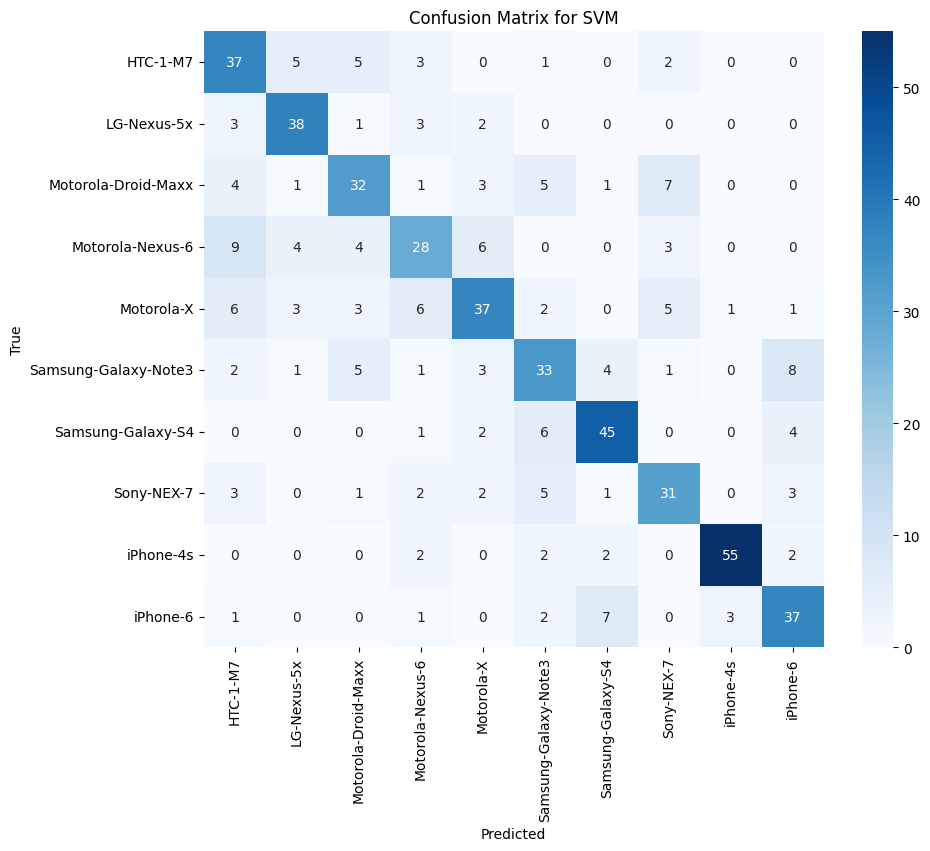

Classification Report for Random Forest:
                      precision    recall  f1-score   support

            HTC-1-M7       0.54      0.72      0.62        53
         LG-Nexus-5x       0.51      0.87      0.64        47
 Motorola-Droid-Maxx       0.68      0.56      0.61        54
    Motorola-Nexus-6       0.45      0.28      0.34        54
          Motorola-X       0.62      0.36      0.46        64
Samsung-Galaxy-Note3       0.57      0.41      0.48        58
   Samsung-Galaxy-S4       0.73      0.78      0.75        58
          Sony-NEX-7       0.58      0.65      0.61        48
           iPhone-4s       0.74      0.87      0.80        63
            iPhone-6       0.59      0.63      0.61        51

            accuracy                           0.61       550
           macro avg       0.60      0.61      0.59       550
        weighted avg       0.61      0.61      0.59       550



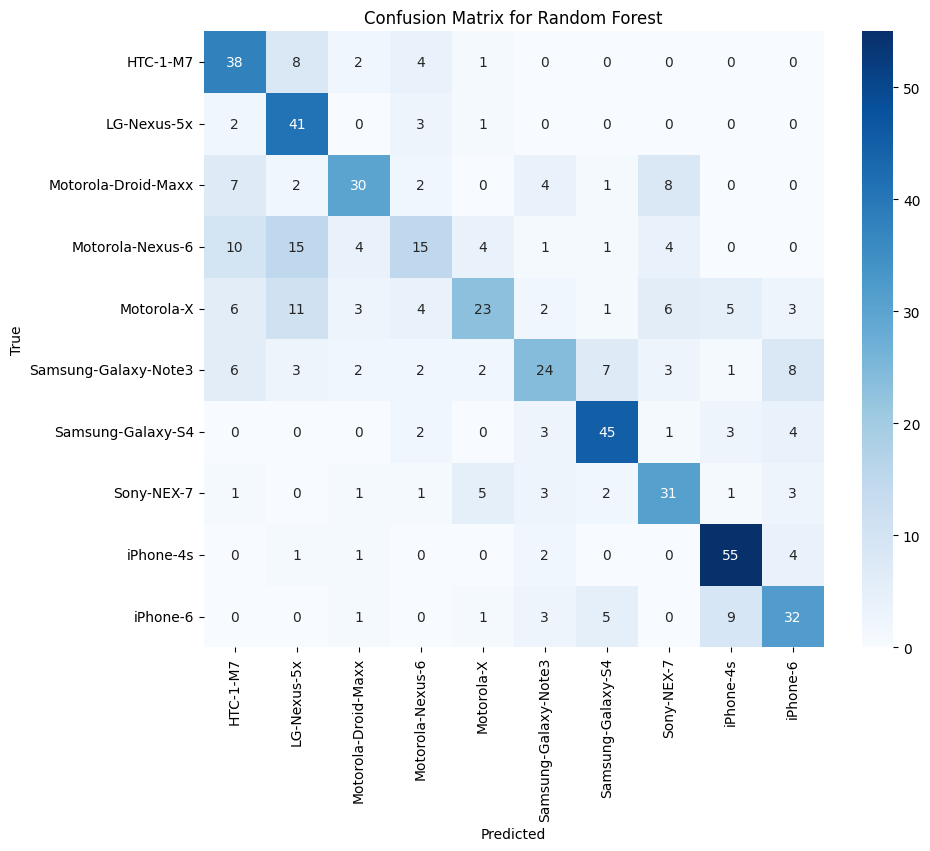

In [4]:
# Step 2: Classification using SVM and Random Forest
# SVM Classifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],                # Regularization parameter
    'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],  # Gamma values
    'kernel': ['rbf']                      # Using the RBF kernel
}

# Instantiate the SVM classifier
svm_model = SVC()

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

# Fit the grid search
grid_search.fit(train_features, y_train)

# Best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")
# Predict with the best model
best_svm_model = grid_search.best_estimator_
svm_predictions = best_svm_model.predict(test_features)

# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model.fit(train_features, y_train)
rf_predictions = rf_model.predict(test_features)

# Evaluation
def evaluate_model(y_true, y_pred, classifier_name):
    print(f"Classification Report for {classifier_name}:")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix for {classifier_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Evaluate SVM
evaluate_model(y_test, svm_predictions, "SVM")

# Evaluate Random Forest
evaluate_model(y_test, rf_predictions, "Random Forest")

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, svm_predictions)
print(f"SVM Accuracy: {accuracy:.4f}")

SVM Accuracy: 0.6782


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# One-hot encode the target labels
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)
model = Sequential([
    Dense(128, activation='relu', input_shape=(train_features.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Output layer with softmax activation
])

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define custom learning rate
learning_rate = 0.0001

# Use Adam optimizer with the custom learning rate
optimizer = Adam(learning_rate=learning_rate)

# Define learning rate scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Compile the model with the new optimizer
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with the learning rate scheduler
history = model.fit(
    train_features, y_train_one_hot, epochs=150, batch_size=10,
    validation_data=(test_features, y_test_one_hot),
    callbacks=[lr_scheduler]  # Learning rate scheduler callback
)

predictions = model.predict(test_features)
predicted_classes = np.argmax(predictions, axis=1)

# Now you can calculate accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(np.argmax(y_test_one_hot, axis=1), predicted_classes)
print(f"Model Accuracy: {accuracy:.4f}")



Epoch 1/150


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1059 - loss: 2.4729 - val_accuracy: 0.1945 - val_loss: 2.2371 - learning_rate: 1.0000e-04
Epoch 2/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1228 - loss: 2.2821 - val_accuracy: 0.2273 - val_loss: 2.1920 - learning_rate: 1.0000e-04
Epoch 3/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1719 - loss: 2.2343 - val_accuracy: 0.2600 - val_loss: 2.0941 - learning_rate: 1.0000e-04
Epoch 4/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2176 - loss: 2.1534 - val_accuracy: 0.3145 - val_loss: 2.0058 - learning_rate: 1.0000e-04
Epoch 5/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2474 - loss: 2.0711 - val_accuracy: 0.3491 - val_loss: 1.9413 - learning_rate: 1.0000e-04
Epoch 6/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2241 - loss: 2.0584 - val_accuracy: 0.3473 - val_loss: 1.8758 - learning_rate: 1.0000e-04
Epoch 7/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.269

**End to End CNN Model**

<Axes: xlabel='class'>

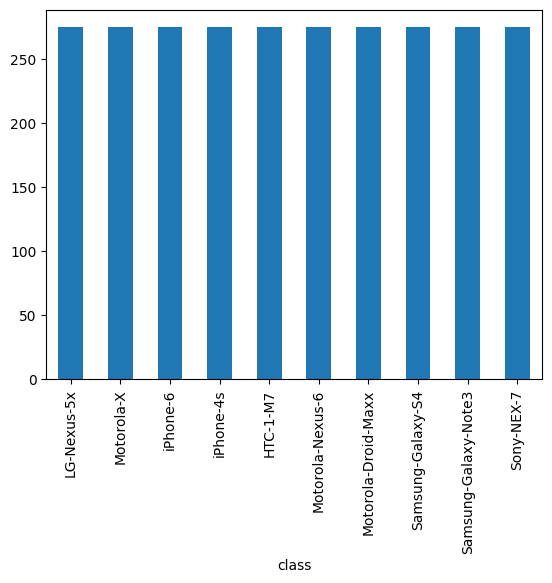

In [27]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A

from sklearn.metrics import f1_score, classification_report
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from numpy import array
from random import shuffle, seed
list_paths = []
for subdir, dirs, files in os.walk("../input"):
    for file in files:
        filepath = subdir + os.sep + file
        list_paths.append(filepath)
        
list_train = [filepath for filepath in list_paths if "train/" in filepath]
seed(420)
shuffle(list_train)
list_test = [filepath for filepath in list_paths if "test/" in filepath]
def get_class_from_path(filepath):
    return os.path.dirname(filepath).split(os.sep)[-1]
labels = [get_class_from_path(filepath) for filepath in list_train]
train_data = pd.DataFrame(labels, columns=['class'])
train_data['path'] = list_train
train_data['class'].value_counts().sort_values().plot(kind='bar')

In [30]:
X = train_data['path']
y = train_data['class']
splitter = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
splits = list(splitter.split(X=X, y=y))
dict_map = {
    "HTC-1-M7": 0,
    "LG-Nexus-5x": 1,
    "Motorola-Droid-Maxx": 2,
    "Motorola-Nexus-6": 3,
    "Motorola-X": 4,
    "Samsung-Galaxy-Note3": 5,
    "Samsung-Galaxy-S4": 6,
    "Sony-NEX-7": 7,
    "iPhone-4s": 8,
    "iPhone-6": 9
}
def open_image(img_path):
    image = cv2.imread(img_path)
#     array_img = np.array(image)
    return image
def preprocess(images):
    return (images / 127.5) - 1.0
SHAPE = 512

train_augmentations = A.Compose([#A.RGBShift(),
                                 A.RandomCrop(height=SHAPE,width=SHAPE),
                                 A.RandomGamma(gamma_limit=(80, 120), p=0.8),
                                #  A.Blur(),
                                #  A.GaussNoise(),
                                 A.ImageCompression(quality_lower=70, quality_upper=90, p=0.9),
                                 A.GridDistortion(interpolation=cv2.INTER_CUBIC, p=0.9)
                                 ])

teste_augmentations = A.Compose([#A.RGBShift(),
                                 A.CenterCrop(height=SHAPE,width=SHAPE)
#                                  A.RandomGamma(),
                                #  A.Blur(),
                                #  A.GaussNoise(),
#                                  A.JpegCompression(quality_lower=70, quality_upper=100, p=0.5),
#                                  A.GridDistortion(interpolation=cv2.INTER_CUBIC, p=0.5)                                 
                                 ])

class CameraDataset(tf.keras.utils.Sequence):
    def __init__(self, X_set, y_set, batch_size, augmenter=None, test=False, *args, **kwargs):
        self.batch_size = batch_size
        self.x_set = X_set
        self.y_set = y_set
        self.test = test
        self.augmenter = augmenter

    def __len__(self):
        return int(len(self.x_set) / self.batch_size)
    
    def __getitem__(self, index):
        # Get a batch of data
        X = self.x_set[index * self.batch_size : (index + 1) * self.batch_size]
        y = self.y_set[index * self.batch_size : (index + 1) * self.batch_size]
        
        # Apply augmentations and ensure correct dtype
        X = [self.augmenter(image=open_image(x))['image'] for x in X]
        X = np.array(X, dtype=np.float32)  # Ensure images are float32
        
        if self.test:
            return X
        
        y = np.array(y, dtype=np.int32)  # Ensure labels are int32
        return X, y




LOCAL_WEIGHTS_PATH = '/kaggle/input/efficientnet/efficientnetb0_notop.h5'



def build_model():
    # Load EfficientNetB0 without the top layer (include_top=False)
    base_model = tf.keras.applications.EfficientNetB0(weights=None, include_top=False, input_shape=[SHAPE, SHAPE, 3])

    base_model.load_weights(LOCAL_WEIGHTS_PATH)
    base_model.trainable = True
    
    # Input layer
    inputs = tf.keras.layers.Input(shape=(SHAPE, SHAPE, 3))
    
    # Preprocess input (specific to EfficientNet)
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    
    # Pass through the base model (EfficientNetB0)
    x = base_model(x, training=True)
    
    # Global average pooling layer
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    
    # Fully connected layers (dense layers)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # Output layer with softmax activation for multi-class classification
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    # Define the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Print model summary
    model.summary()
    
    return model


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)
# Convert string labels to integer labels
y_train_encoded = [dict_map[label] for label in y_train]
y_test_encoded = [dict_map[label] for label in y_test]

# Convert to NumPy arrays with correct dtype
y_train_encoded = np.array(y_train_encoded, dtype=np.int32)
y_test_encoded = np.array(y_test_encoded, dtype=np.int32)

# Split data
train_dataset = CameraDataset(X_train, y_train_encoded, batch_size=10, augmenter=train_augmentations)
val_dataset = CameraDataset(X_test, y_test_encoded, batch_size=10, augmenter=teste_augmentations)
model = build_model()

# Callbacks
file_path = "output/weights.best.hdf5.keras"
checkpoint = tf.keras.callbacks.ModelCheckpoint(file_path, monitor="val_accuracy", save_best_only=True, mode="max")
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.9, patience=2, min_lr=1e-6, mode="max", verbose=True)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, mode="max", verbose=True)
callbacks_list = [checkpoint, reduce_lr, early_stopping]

# Train the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10, callbacks=callbacks_list)

# Load and continue training
for n in range(2):
    print(f"Epoch set {n}")
    if n > 0:
        model = tf.keras.models.load_model(file_path)
    
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=10, callbacks=callbacks_list)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 16, 16, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,133,965 (15.77 MB)

 Trainable params: 4,091,942 (15.61 MB)

 Non-trainable params: 42,023 (164.16 KB)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


220/220 ━━━━━━━━━━━━━━━━━━━━ 411s 1s/step - accuracy: 0.1483 - loss: 2.2936 - val_accuracy: 0.1855 - val_loss: 2.2100 - learning_rate: 1.0000e-04
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.2218 - loss: 2.1213 - val_accuracy: 0.4527 - val_loss: 1.7179 - learning_rate: 1.0000e-04
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.3486 - loss: 1.8644 - val_accuracy: 0.6436 - val_loss: 1.2065 - learning_rate: 1.0000e-04
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.4354 - loss: 1.6726 - val_accuracy: 0.7182 - val_loss: 0.9204 - learning_rate: 1.0000e-04
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.5038 - loss: 1.4566 - val_accuracy: 0.7836 - val_loss: 0.7145 - learning_rate: 1.0000e-04
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.5700 - loss: 1.3050 - val_accuracy: 0.8400 - val_loss: 0.5731 - learning_rate: 1.0000e-04
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.62

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 8: Evaluate the model
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# Confusion Matrix
y_pred = model.predict(val_dataset)

55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9615 - loss: 0.1276
Validation Accuracy: 96.36%
55/55 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step


ValueError: `axis` must be fewer than the number of dimensions (1)

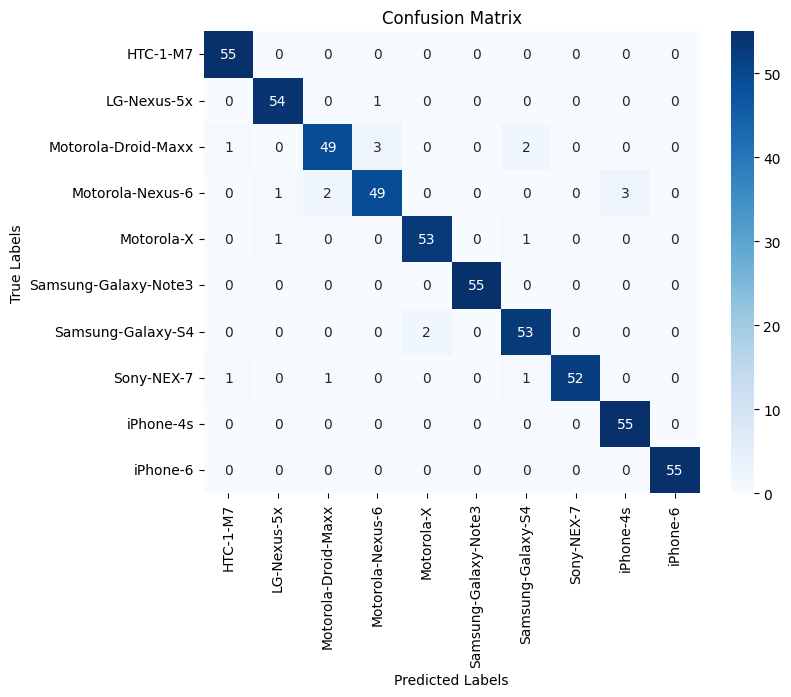

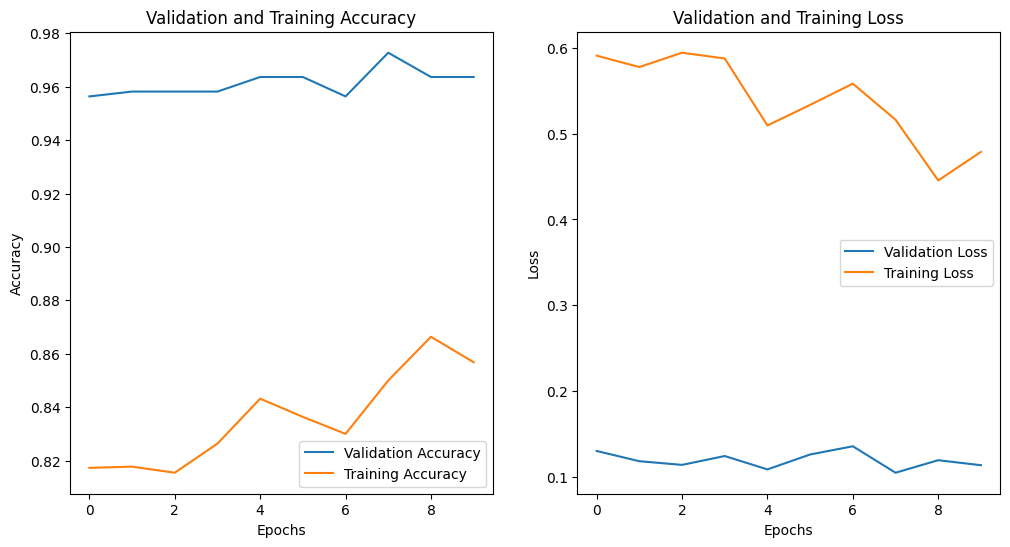

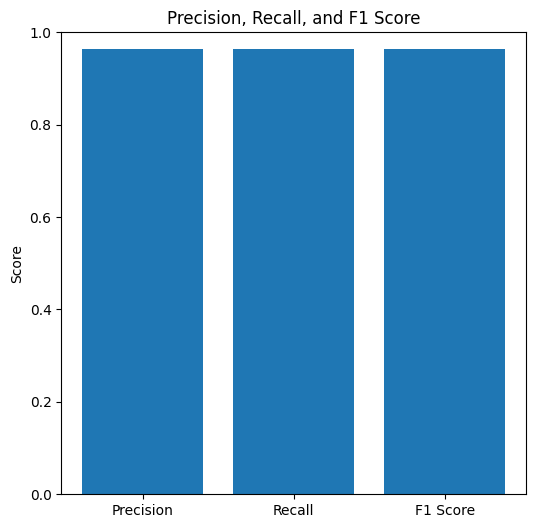

55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step


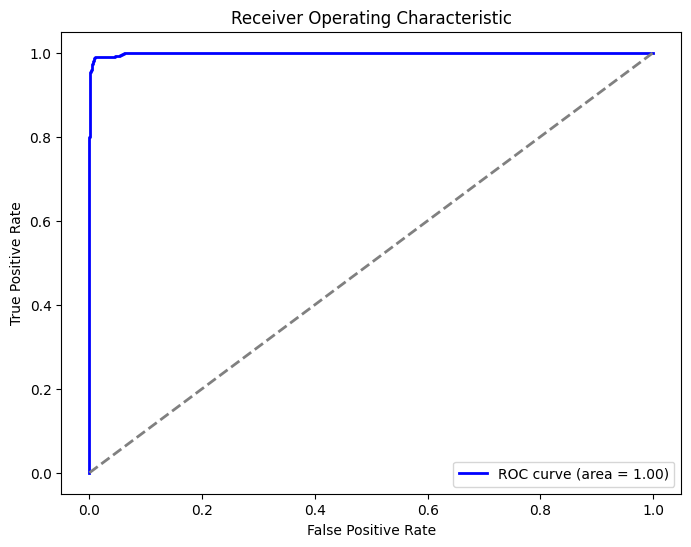

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

reversed_dict_map = {
    0: "HTC-1-M7",
    1: "LG-Nexus-5x",
    2: "Motorola-Droid-Maxx",
    3: "Motorola-Nexus-6",
    4: "Motorola-X",
    5: "Samsung-Galaxy-Note3",
    6: "Samsung-Galaxy-S4",
    7: "Sony-NEX-7",
    8: "iPhone-4s",
    9: "iPhone-6"
}

y_pred_classes = np.argmax(y_pred, axis=1)
# y_true_classes = [dict_map[value] for value in y_test]
y_true_classes = y_test_encoded

# Map numerical labels to string labels
y_pred_labels = [reversed_dict_map[label] for label in y_pred_classes]

# Map numerical labels to string labels
y_true_labels = [reversed_dict_map[label] for label in y_true_classes]

conf_matrix = confusion_matrix(y_true_labels, y_pred_labels, labels=list(reversed_dict_map.values()))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=reversed_dict_map.values(), yticklabels=reversed_dict_map.values())
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Validation accuracy and loss plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Validation and Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Validation and Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Precision, Recall, and F1 Score plot
precision, recall, f1, _ = precision_recall_fscore_support(y_true_classes, y_pred_classes, average='weighted')

metrics = [precision, recall, f1]
metrics_labels = ['Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(6, 6))
plt.bar(metrics_labels, metrics)
plt.title('Precision, Recall, and F1 Score')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.show()

# ROC Curve
y_true_bin = label_binarize(y_true_classes, classes=np.arange(10))  # 10 classes
y_pred_prob = model.predict(val_dataset)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()